# Preprocessed Output Inspection Tool

Visual inspection and quality validation of preprocessing pipeline outputs.  
Load a sample from `preprocessed/<label>/<video_stem>/`, inspect every artifact, and verify correctness.

**Outputs inspected:** `frames.npy`, `keypoints.npy`, `flow_vectors.npy`, `flow_magnitudes.npy`, `masks.npy`, `attention_mask.npy`, `metadata.json`

In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import hsv_to_rgb
from IPython.display import display, HTML
import ipywidgets as widgets

plt.rcParams.update({
    "figure.facecolor": "#1e1e1e",
    "axes.facecolor": "#1e1e1e",
    "axes.edgecolor": "#555",
    "axes.labelcolor": "#ccc",
    "text.color": "#ccc",
    "xtick.color": "#999",
    "ytick.color": "#999",
    "figure.dpi": 100,
})

## 1. Load Sample

Point `SAMPLE_DIR` to a preprocessed sample folder. All `.npy` files and `metadata.json` are loaded.

In [3]:
# ── CONFIGURE THIS ──────────────────────────────────────────────────────────
PREPROCESSED_ROOT = Path("../preprocessed")

# Auto-discover available samples
samples = sorted(
    p.parent
    for p in PREPROCESSED_ROOT.rglob("metadata.json")
    if not p.parent.name.startswith("_")
)
print(f"Found {len(samples)} preprocessed sample(s):")
for i, s in enumerate(samples):
    print(f"  [{i}] {s.relative_to(PREPROCESSED_ROOT)}")

# Select sample index (change this to inspect a different sample)
SAMPLE_IDX = 0
SAMPLE_DIR = samples[SAMPLE_IDX]
print(f"\n▶ Inspecting: {SAMPLE_DIR}")

Found 1 preprocessed sample(s):
  [0] who\who_63229

▶ Inspecting: ..\preprocessed\who\who_63229


In [4]:
# Load all artifacts
frames = np.load(SAMPLE_DIR / "frames.npy")
keypoints = np.load(SAMPLE_DIR / "keypoints.npy")
attention_mask = np.load(SAMPLE_DIR / "attention_mask.npy")

flow_vectors = None
flow_magnitudes = None
masks = None

if (SAMPLE_DIR / "flow_vectors.npy").exists():
    flow_vectors = np.load(SAMPLE_DIR / "flow_vectors.npy")
if (SAMPLE_DIR / "flow_magnitudes.npy").exists():
    flow_magnitudes = np.load(SAMPLE_DIR / "flow_magnitudes.npy")
if (SAMPLE_DIR / "masks.npy").exists():
    masks = np.load(SAMPLE_DIR / "masks.npy")

with open(SAMPLE_DIR / "metadata.json", encoding="utf-8") as f:
    metadata = json.load(f)

T, H, W, _ = frames.shape
n_real = int(attention_mask.sum())
n_padded = T - n_real

print("Artifact shapes:")
print(f"  frames          {frames.shape}  {frames.dtype}")
print(f"  keypoints       {keypoints.shape}  {keypoints.dtype}")
print(f"  attention_mask  {attention_mask.shape}  {attention_mask.dtype}")
if flow_vectors is not None:
    print(f"  flow_vectors    {flow_vectors.shape}  {flow_vectors.dtype}")
if flow_magnitudes is not None:
    print(f"  flow_magnitudes {flow_magnitudes.shape}  {flow_magnitudes.dtype}")
if masks is not None:
    print(f"  masks           {masks.shape}  {masks.dtype}")
print(f"\nReal frames: {n_real}  |  Padded: {n_padded}  |  Sequence length: {T}")

Artifact shapes:
  frames          (32, 290, 256, 3)  uint8
  keypoints       (32, 258)  float32
  attention_mask  (32,)  float32
  flow_vectors    (31, 290, 256, 2)  float32
  flow_magnitudes (31, 290, 256)  float32
  masks           (32, 290, 256)  uint8

Real frames: 30  |  Padded: 2  |  Sequence length: 32


## 2. Metadata & Provenance

In [5]:
# Pretty-print metadata
def _fmt_meta(meta: dict) -> str:
    lines = []
    for k, v in meta.items():
        if isinstance(v, dict):
            lines.append(f"  {k}:")
            for k2, v2 in v.items():
                lines.append(f"    {k2}: {v2}")
        elif isinstance(v, list) and len(v) > 8:
            lines.append(f"  {k}: [{v[0]}, {v[1]}, ... {v[-1]}] ({len(v)} items)")
        else:
            lines.append(f"  {k}: {v}")
    return "\n".join(lines)

print(_fmt_meta(metadata))

  source_video: who_63229.mp4
  label: who
  original_frame_count: 49
  trimmed_frame_count: 30
  trim_range: [12, 41]
  crop_bbox: [703, 263, 1424, 1080]
  crop_size: [290, 256]
  keypoint_confidence_mean: 0.5929
  target_fps: 25
  target_sequence_length: 32
  flow_computed: True
  pipeline_version: 1.0.0
  processing_timestamp: 2026-03-11T20:13:55.759999+00:00


## 3. Frame Gallery

Visual overview of all frames. **Green border** = real frame, **Red border** = padded (repeated last frame).

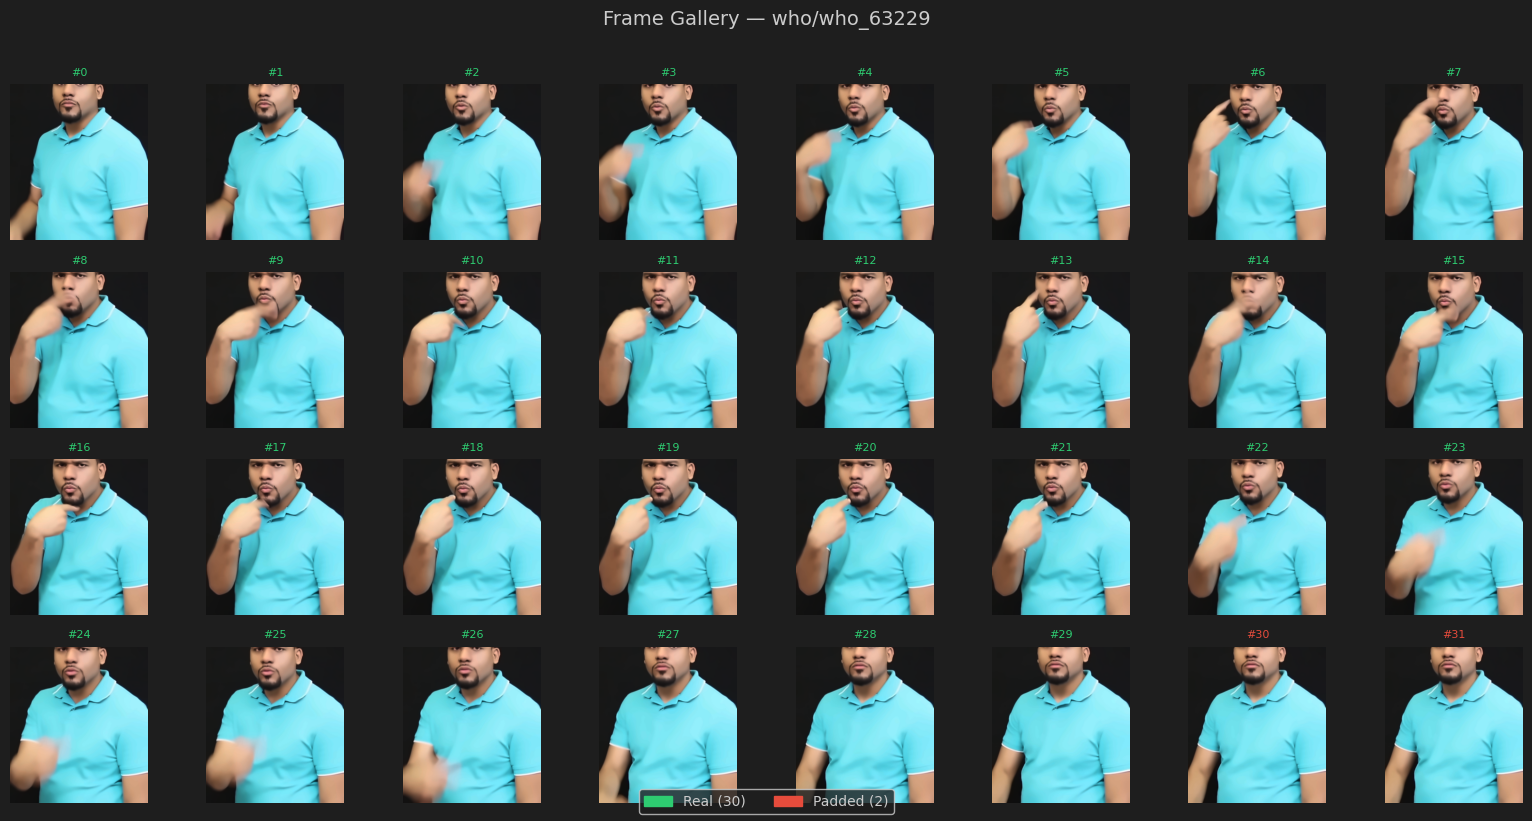

In [6]:
COLS = 8
rows = (T + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2, rows * 2))
axes = np.atleast_2d(axes)

for i in range(rows * COLS):
    ax = axes[i // COLS, i % COLS]
    ax.axis("off")
    if i < T:
        ax.imshow(frames[i])
        is_real = attention_mask[i] > 0.5
        color = "#2ecc71" if is_real else "#e74c3c"
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)
        ax.set_title(f"#{i}", fontsize=8, color=color)

real_patch = mpatches.Patch(color="#2ecc71", label=f"Real ({n_real})")
pad_patch = mpatches.Patch(color="#e74c3c", label=f"Padded ({n_padded})")
fig.legend(handles=[real_patch, pad_patch], loc="lower center", ncol=2, fontsize=10)
fig.suptitle(f"Frame Gallery — {metadata.get('label', '?')}/{SAMPLE_DIR.name}",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Keypoint Skeleton Overlay

MediaPipe pose (33 landmarks) + hand (21×2 landmarks) drawn on frames.  
Use the slider to scrub through frames.

In [7]:
# MediaPipe Pose skeleton connections
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),  # face
    (9,10),  # mouth
    (11,12), # shoulders
    (11,13),(13,15),(15,17),(15,19),(15,21),(17,19),  # left arm
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),  # right arm
    (11,23),(12,24),(23,24),  # torso
    (23,25),(25,27),(27,29),(27,31),(29,31),  # left leg
    (24,26),(26,28),(28,30),(28,32),(30,32),  # right leg
]

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),      # thumb
    (0,5),(5,6),(6,7),(7,8),      # index
    (0,9),(9,10),(10,11),(11,12), # middle
    (0,13),(13,14),(14,15),(15,16), # ring
    (0,17),(17,18),(18,19),(19,20), # pinky
    (5,9),(9,13),(13,17),          # palm
]


def _draw_skeleton(ax, frame, kp, h, w):
    """Draw pose + hand skeleton on a frame."""
    ax.imshow(frame)

    # Pose landmarks: indices 0-131, groups of 4 (x, y, z, vis)
    pose_xy = []
    pose_vis = []
    for j in range(33):
        x = kp[j * 4] * w
        y = kp[j * 4 + 1] * h
        vis = kp[j * 4 + 3]
        pose_xy.append((x, y))
        pose_vis.append(vis)

    # Draw pose connections
    for (a, b) in POSE_CONNECTIONS:
        if pose_vis[a] > 0.3 and pose_vis[b] > 0.3:
            ax.plot(
                [pose_xy[a][0], pose_xy[b][0]],
                [pose_xy[a][1], pose_xy[b][1]],
                color="#00ff88", linewidth=1.2, alpha=0.8
            )

    # Draw pose points
    for j, (x, y) in enumerate(pose_xy):
        if pose_vis[j] > 0.3:
            ax.plot(x, y, "o", color="#00ff88", markersize=3, alpha=0.9)

    # Hands: left starts at 132, right at 195; groups of 3 (x, y, z)
    for hand_offset, color in [(132, "#ff6b6b"), (195, "#4ecdc4")]:
        hand_xy = []
        has_hand = False
        for j in range(21):
            x = kp[hand_offset + j * 3] * w
            y = kp[hand_offset + j * 3 + 1] * h
            hand_xy.append((x, y))
            if kp[hand_offset + j * 3] > 0:
                has_hand = True

        if not has_hand:
            continue

        for (a, b) in HAND_CONNECTIONS:
            ax.plot(
                [hand_xy[a][0], hand_xy[b][0]],
                [hand_xy[a][1], hand_xy[b][1]],
                color=color, linewidth=1.0, alpha=0.8
            )
        for (x, y) in hand_xy:
            ax.plot(x, y, "o", color=color, markersize=2)


def show_skeleton_frame(frame_idx):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    _draw_skeleton(ax, frames[frame_idx], keypoints[frame_idx], H, W)
    status = "REAL" if attention_mask[frame_idx] > 0.5 else "PADDED"
    ax.set_title(f"Frame #{frame_idx}  [{status}]", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


slider = widgets.IntSlider(
    value=0, min=0, max=T - 1, step=1,
    description="Frame:", continuous_update=False,
    style={"description_width": "60px"},
    layout=widgets.Layout(width="600px"),
)
widgets.interactive(show_skeleton_frame, frame_idx=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='6…

### 4b. Skeleton Overlay Grid (All Frames)

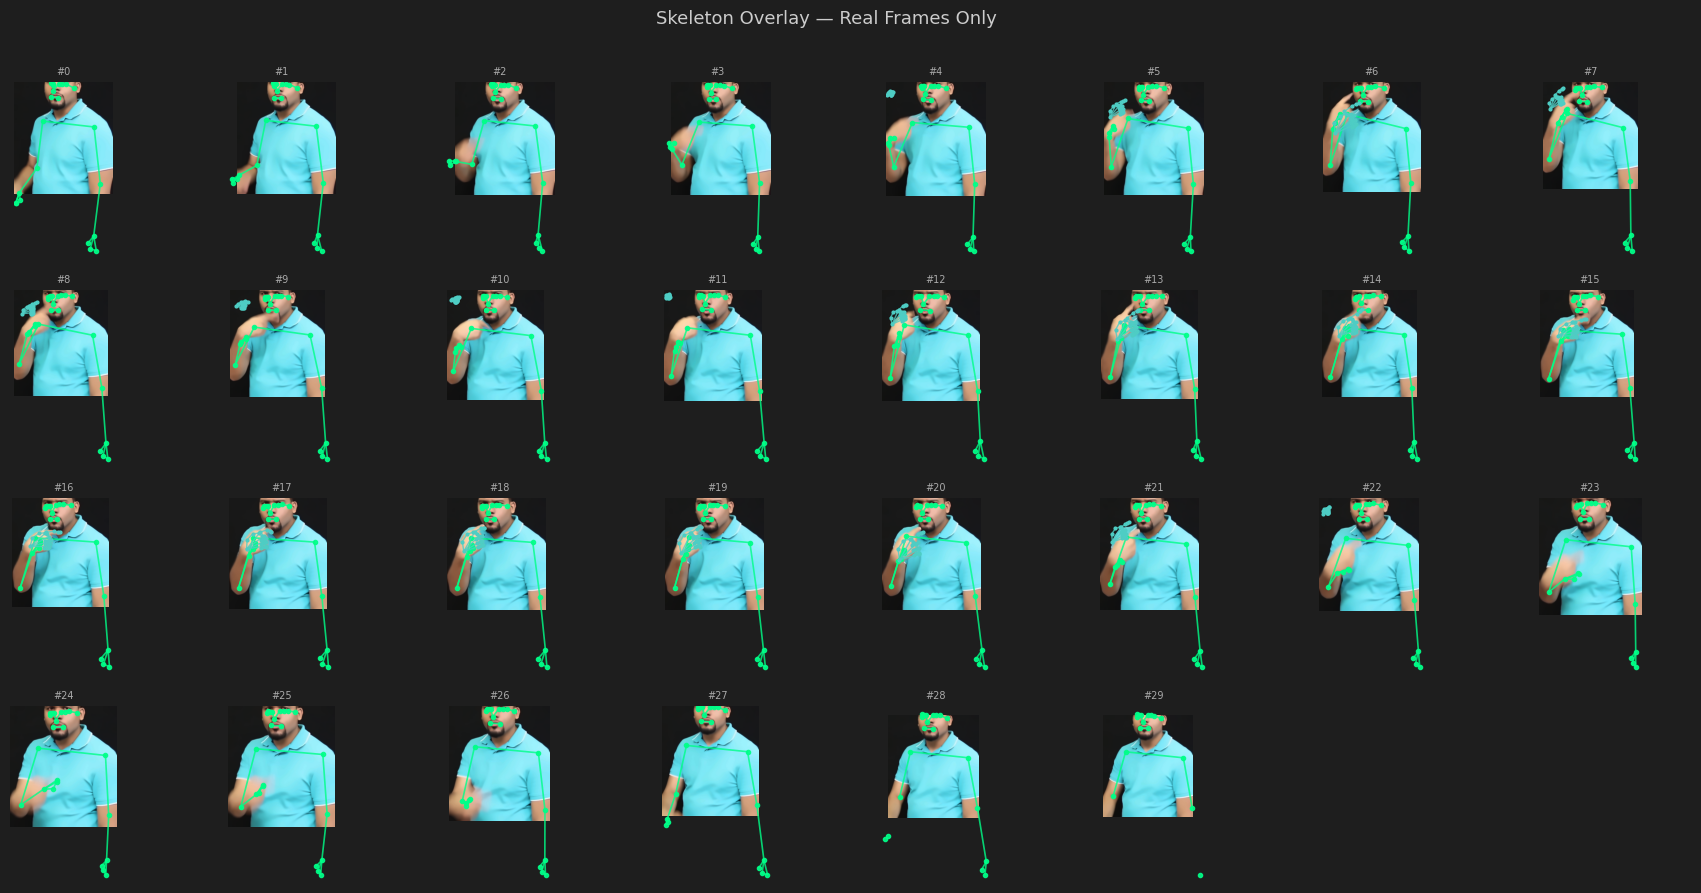

In [8]:
# Grid of all frames with skeleton overlay
COLS = 8
show_n = n_real  # only real frames
rows = (show_n + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2.2, rows * 2.2))
axes = np.atleast_2d(axes)

for i in range(rows * COLS):
    ax = axes[i // COLS, i % COLS]
    ax.axis("off")
    if i < show_n:
        _draw_skeleton(ax, frames[i], keypoints[i], H, W)
        ax.set_title(f"#{i}", fontsize=7, color="#aaa")

fig.suptitle("Skeleton Overlay — Real Frames Only", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Keypoint Analytics

Temporal smoothness, confidence, and per-landmark analysis.

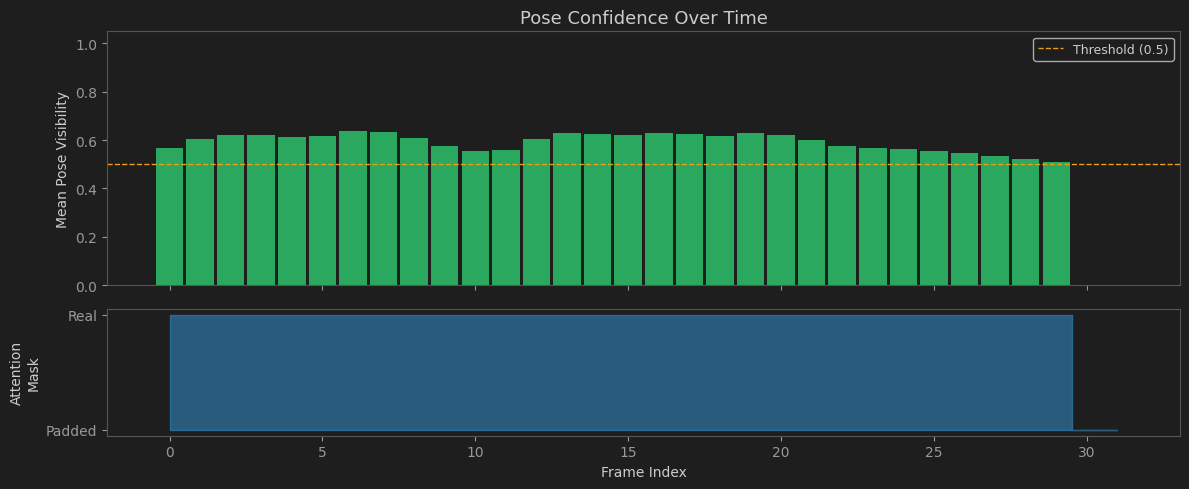

Mean confidence (real frames): 0.593
Min  confidence (real frames): 0.008
Frames with confidence < 0.5:  0/30


In [9]:
# ── 5a. Pose confidence over time ──
vis_indices = list(range(3, 132, 4))  # visibility values
vis_per_frame = keypoints[:, vis_indices]
mean_vis = vis_per_frame.mean(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Confidence curve
colors = ["#2ecc71" if attention_mask[i] > 0.5 else "#e74c3c" for i in range(T)]
ax1.bar(range(T), mean_vis, color=colors, alpha=0.8, width=0.9)
ax1.axhline(0.5, color="#f39c12", linestyle="--", linewidth=1, label="Threshold (0.5)")
ax1.set_ylabel("Mean Pose Visibility")
ax1.set_title("Pose Confidence Over Time", fontsize=13)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.05)

# Attention mask
ax2.fill_between(range(T), attention_mask, step="mid", alpha=0.5, color="#3498db")
ax2.set_ylabel("Attention\nMask")
ax2.set_xlabel("Frame Index")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Padded", "Real"])

plt.tight_layout()
plt.show()

# Stats
valid_vis = vis_per_frame[attention_mask > 0.5]
if valid_vis.size:
    print(f"Mean confidence (real frames): {valid_vis.mean():.3f}")
    print(f"Min  confidence (real frames): {valid_vis.min():.3f}")
    low_count = (valid_vis.mean(axis=1) < 0.5).sum()
    print(f"Frames with confidence < 0.5:  {low_count}/{n_real}")

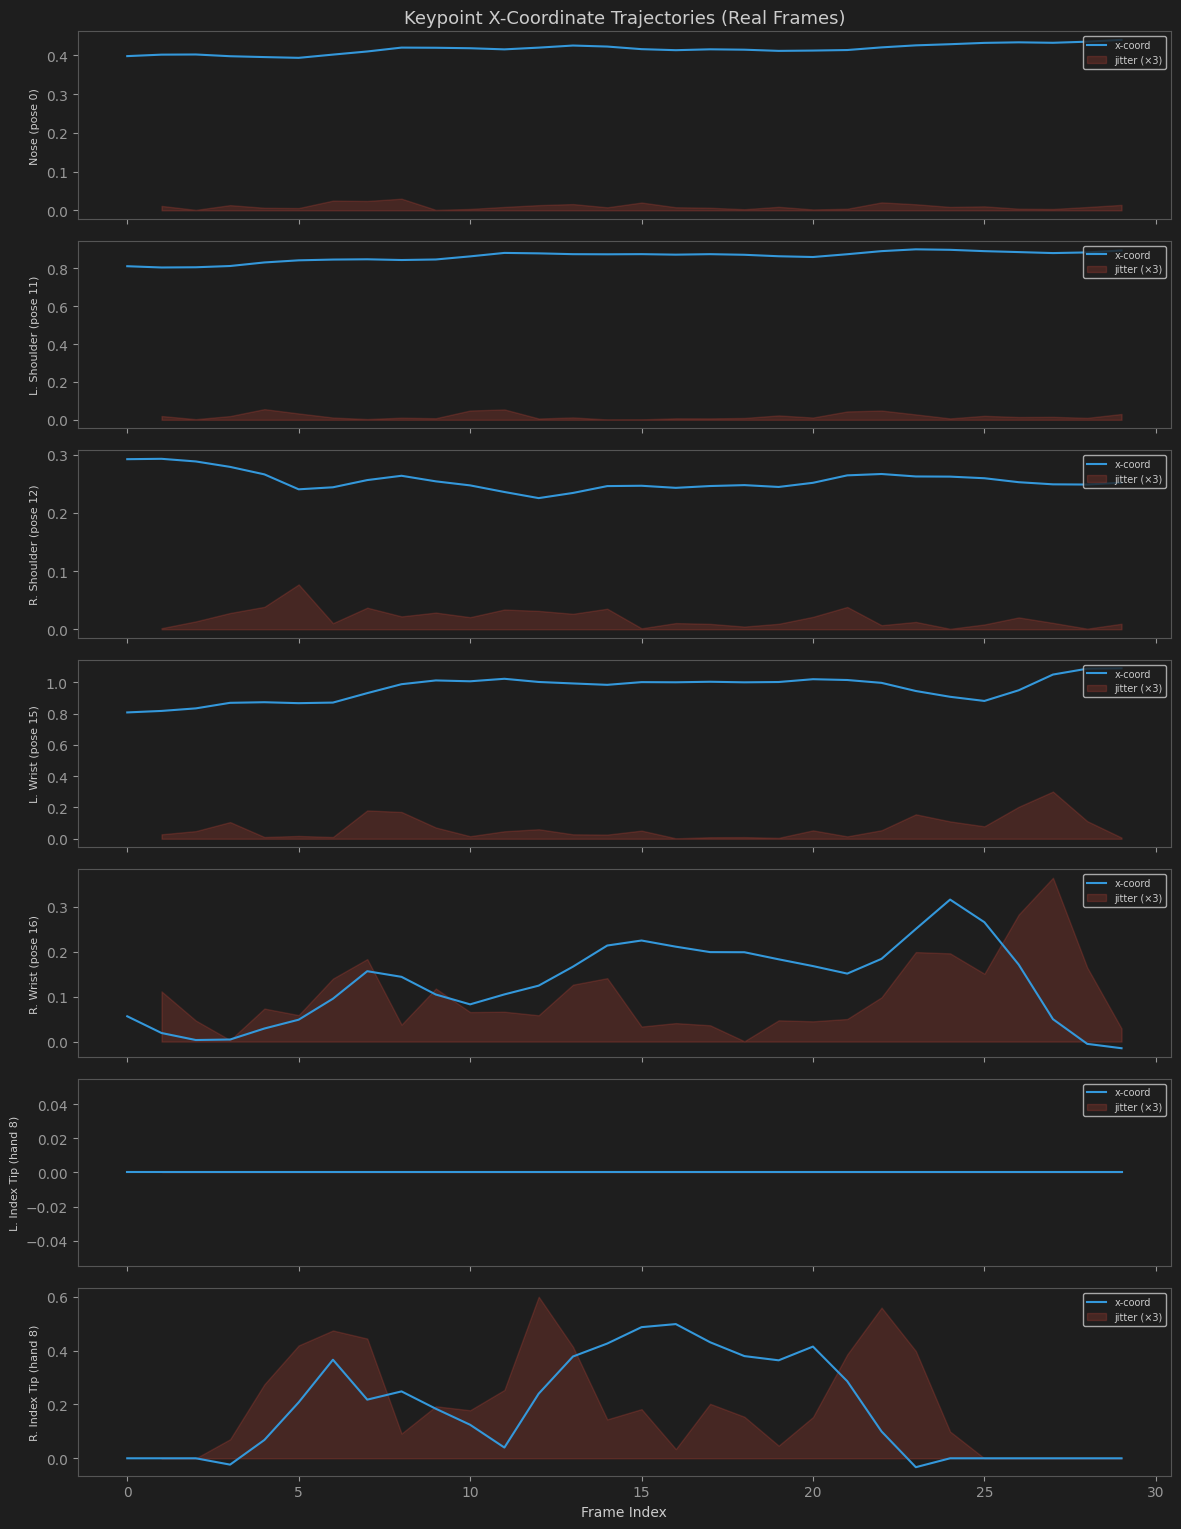

In [10]:
# ── 5b. Keypoint temporal smoothness ──
# Plot x-coordinates of key landmarks over time to verify Savitzky-Golay smoothing

LANDMARKS_TO_PLOT = {
    "Nose (pose 0)": 0,
    "L. Shoulder (pose 11)": 11 * 4,
    "R. Shoulder (pose 12)": 12 * 4,
    "L. Wrist (pose 15)": 15 * 4,
    "R. Wrist (pose 16)": 16 * 4,
    "L. Index Tip (hand 8)": 132 + 8 * 3,
    "R. Index Tip (hand 8)": 195 + 8 * 3,
}

fig, axes = plt.subplots(len(LANDMARKS_TO_PLOT), 1, figsize=(12, 2.2 * len(LANDMARKS_TO_PLOT)),
                         sharex=True)

for ax, (name, idx) in zip(axes, LANDMARKS_TO_PLOT.items()):
    x_vals = keypoints[:n_real, idx]  # only real frames
    ax.plot(x_vals, color="#3498db", linewidth=1.5, label="x-coord")
    # Compute jitter (frame-to-frame delta)
    if len(x_vals) > 1:
        jitter = np.abs(np.diff(x_vals))
        ax.fill_between(range(1, len(x_vals)), 0, jitter * 3,
                        alpha=0.2, color="#e74c3c", label="jitter (×3)")
    ax.set_ylabel(name, fontsize=8)
    ax.legend(fontsize=7, loc="upper right")

axes[0].set_title("Keypoint X-Coordinate Trajectories (Real Frames)", fontsize=13)
axes[-1].set_xlabel("Frame Index")
plt.tight_layout()
plt.show()

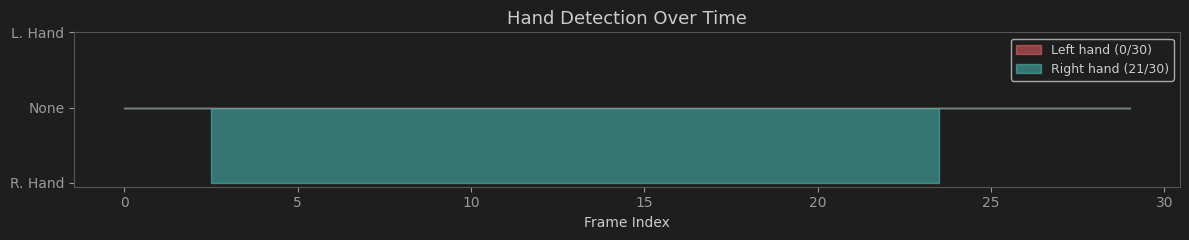

In [11]:
# ── 5c. Hand detection rate ──
left_hand_block = keypoints[:n_real, 132:195]
right_hand_block = keypoints[:n_real, 195:258]

left_detected = (np.abs(left_hand_block).sum(axis=1) > 0).astype(int)
right_detected = (np.abs(right_hand_block).sum(axis=1) > 0).astype(int)

fig, ax = plt.subplots(figsize=(12, 2.5))

ax.fill_between(range(n_real), 0, left_detected, alpha=0.5, step="mid",
                color="#ff6b6b", label=f"Left hand ({left_detected.sum()}/{n_real})")
ax.fill_between(range(n_real), 0, -right_detected, alpha=0.5, step="mid",
                color="#4ecdc4", label=f"Right hand ({right_detected.sum()}/{n_real})")

ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["R. Hand", "None", "L. Hand"])
ax.set_xlabel("Frame Index")
ax.set_title("Hand Detection Over Time", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Optical Flow Inspection

HSV color-wheel visualization: **Hue** = flow direction, **Brightness** = magnitude.  
Plus per-frame magnitude heatmaps.

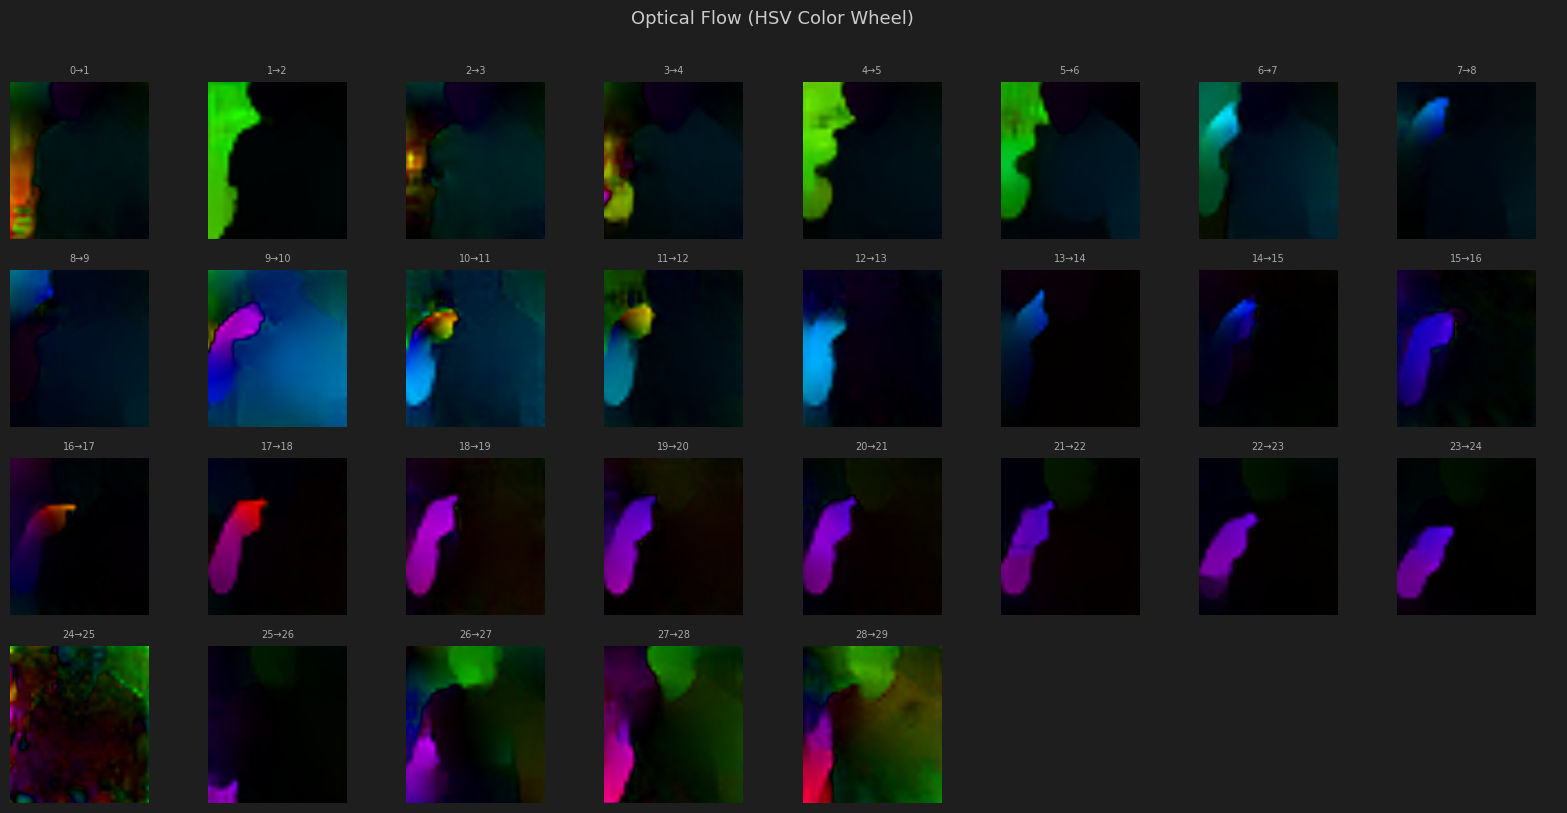

In [12]:
def flow_to_rgb(flow_uv: np.ndarray) -> np.ndarray:
    """Convert (H, W, 2) optical flow to RGB using HSV color wheel."""
    u, v = flow_uv[..., 0], flow_uv[..., 1]
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v, u)

    hsv = np.zeros((*flow_uv.shape[:2], 3), dtype=np.float64)
    hsv[..., 0] = (angle + np.pi) / (2 * np.pi)  # hue
    hsv[..., 1] = 1.0                              # saturation
    hsv[..., 2] = np.clip(mag / (mag.max() + 1e-8), 0, 1)  # value

    return (hsv_to_rgb(hsv) * 255).astype(np.uint8)


if flow_vectors is not None:
    n_flow = min(n_real - 1, flow_vectors.shape[0])
    COLS = 8
    rows = (n_flow + COLS - 1) // COLS

    fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2, rows * 2))
    axes = np.atleast_2d(axes)

    for i in range(rows * COLS):
        ax = axes[i // COLS, i % COLS]
        ax.axis("off")
        if i < n_flow:
            rgb = flow_to_rgb(flow_vectors[i])
            ax.imshow(rgb)
            ax.set_title(f"{i}→{i+1}", fontsize=7, color="#aaa")

    fig.suptitle("Optical Flow (HSV Color Wheel)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ flow_vectors.npy not found — optical flow was skipped (--skip-flow).")

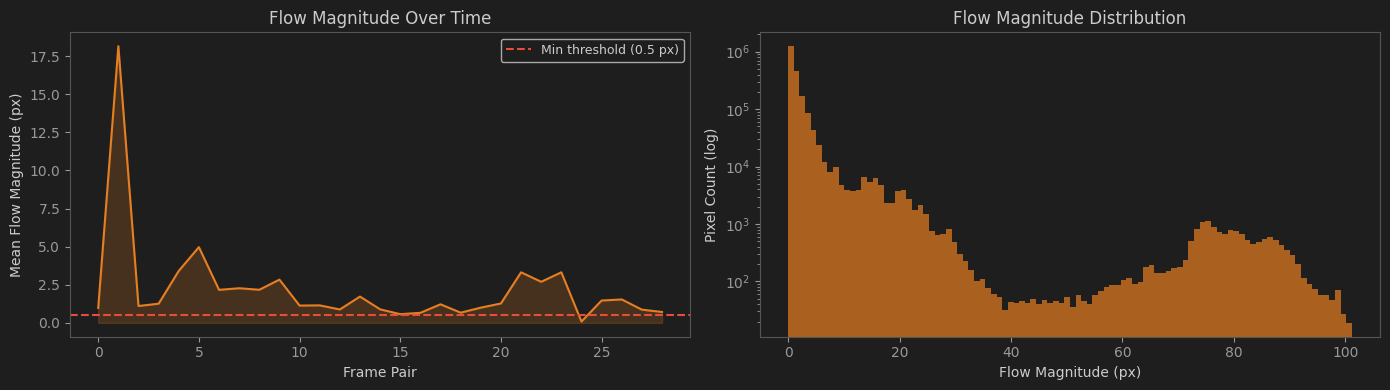

Global mean flow magnitude: 2.224 px
Peak flow at pair: 1 (18.15 px)


In [13]:
# ── 6b. Flow magnitude statistics ──
if flow_magnitudes is not None:
    n_flow = min(n_real - 1, flow_magnitudes.shape[0])
    mag_per_frame = [flow_magnitudes[i].mean() for i in range(n_flow)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Line plot
    ax1.plot(mag_per_frame, color="#e67e22", linewidth=1.5)
    ax1.fill_between(range(n_flow), mag_per_frame, alpha=0.2, color="#e67e22")
    ax1.axhline(0.5, color="#e74c3c", linestyle="--", label="Min threshold (0.5 px)")
    ax1.set_xlabel("Frame Pair")
    ax1.set_ylabel("Mean Flow Magnitude (px)")
    ax1.set_title("Flow Magnitude Over Time", fontsize=12)
    ax1.legend(fontsize=9)

    # Distribution
    ax2.hist(flow_magnitudes[:n_flow].ravel(), bins=100, color="#e67e22",
             alpha=0.7, log=True)
    ax2.set_xlabel("Flow Magnitude (px)")
    ax2.set_ylabel("Pixel Count (log)")
    ax2.set_title("Flow Magnitude Distribution", fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"Global mean flow magnitude: {flow_magnitudes[:n_flow].mean():.3f} px")
    print(f"Peak flow at pair: {np.argmax(mag_per_frame)} "
          f"({max(mag_per_frame):.2f} px)")
else:
    print("⚠ flow_magnitudes.npy not found.")

## 7. Motion Mask Inspection

Binary masks overlaid on frames — should highlight the signer's body/hands, not background.

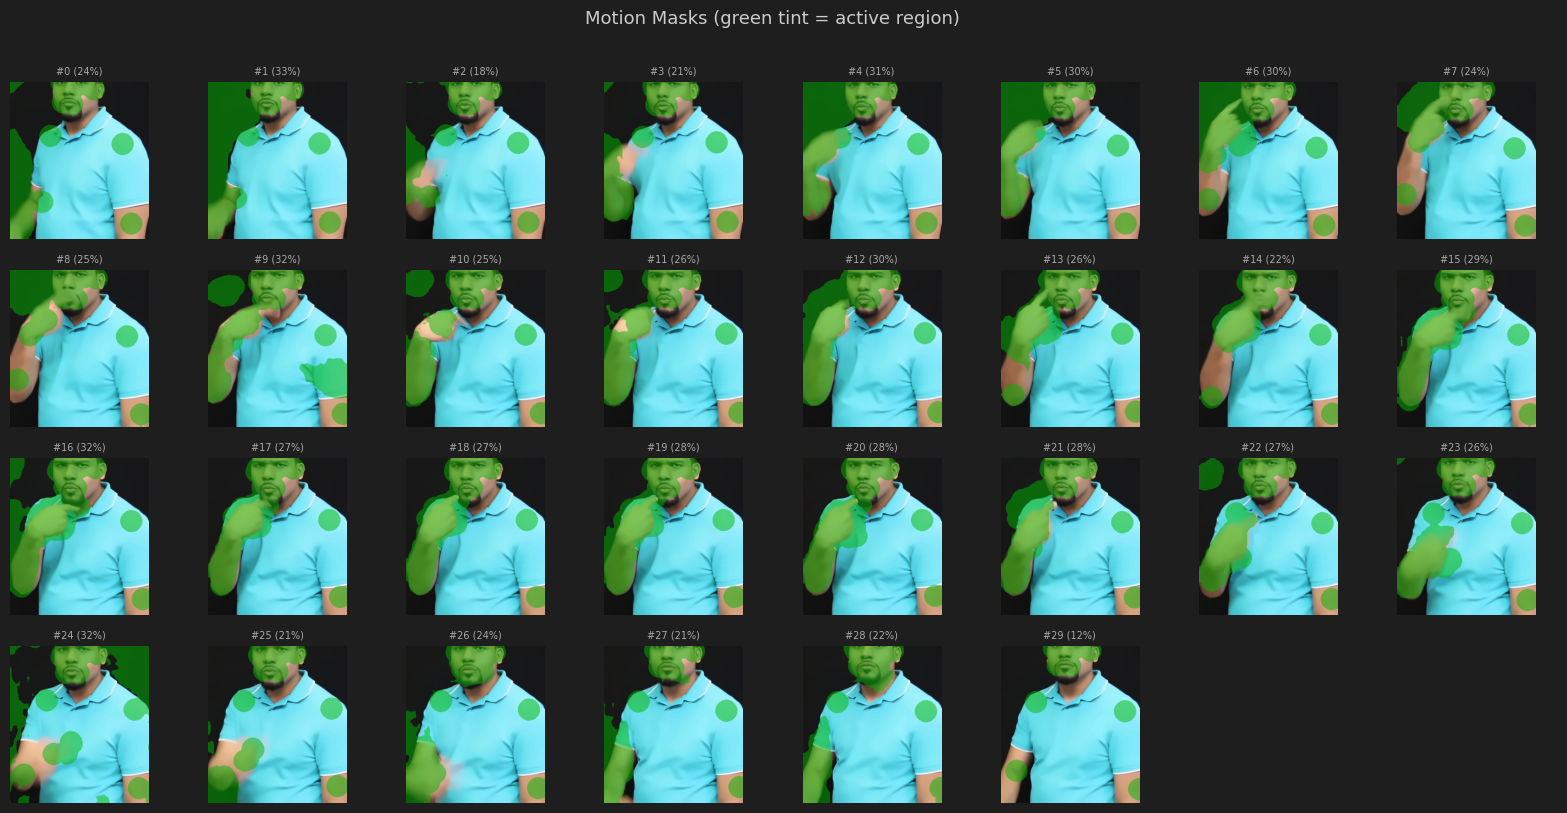

Mask coverage — mean: 26.0%  min: 12.2%  max: 33.0%


In [14]:
if masks is not None:
    COLS = 8
    show_n_masks = n_real
    rows = (show_n_masks + COLS - 1) // COLS
    fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2, rows * 2))
    axes = np.atleast_2d(axes)

    for i in range(rows * COLS):
        ax = axes[i // COLS, i % COLS]
        ax.axis("off")
        if i < show_n_masks:
            # Overlay mask on frame
            overlay = frames[i].copy()
            mask_bool = masks[i] > 127
            # Tint masked region green
            green = np.zeros_like(overlay)
            green[..., 1] = 180
            overlay[mask_bool] = (
                overlay[mask_bool].astype(np.float32) * 0.5 +
                green[mask_bool].astype(np.float32) * 0.5
            ).astype(np.uint8)
            ax.imshow(overlay)
            pct = mask_bool.sum() / mask_bool.size * 100
            ax.set_title(f"#{i} ({pct:.0f}%)", fontsize=7, color="#aaa")

    fig.suptitle("Motion Masks (green tint = active region)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Coverage stats
    real_masks = masks[:n_real]
    coverage = (real_masks > 127).sum(axis=(1, 2)) / (H * W) * 100
    print(f"Mask coverage — mean: {coverage.mean():.1f}%  "
          f"min: {coverage.min():.1f}%  max: {coverage.max():.1f}%")
else:
    print("⚠ masks.npy not found.")

## 8. Shape Consistency Audit

Verify all array dimensions are consistent with each other and the pipeline config.

In [15]:
# Shape audit
checks = []

def _check(name: str, condition: bool, detail: str):
    status = "✅" if condition else "❌"
    checks.append((status, name, detail))

_check("Frames temporal dim",
       frames.shape[0] == T,
       f"frames.shape[0]={frames.shape[0]}, expected {T}")

_check("Keypoints temporal dim",
       keypoints.shape[0] == T,
       f"keypoints.shape[0]={keypoints.shape[0]}, expected {T}")

_check("Keypoints feature dim",
       keypoints.shape[1] == 258,
       f"keypoints.shape[1]={keypoints.shape[1]}, expected 258")

_check("Attention mask length",
       attention_mask.shape[0] == T,
       f"attention_mask.shape[0]={attention_mask.shape[0]}, expected {T}")

if flow_vectors is not None:
    _check("Flow vectors temporal dim",
           flow_vectors.shape[0] == T - 1,
           f"flow_vectors.shape[0]={flow_vectors.shape[0]}, expected {T-1}")
    _check("Flow vectors spatial match",
           flow_vectors.shape[1:3] == (H, W),
           f"flow spatial={flow_vectors.shape[1:3]}, frames spatial=({H},{W})")

if flow_magnitudes is not None:
    _check("Flow magnitudes temporal dim",
           flow_magnitudes.shape[0] == T - 1,
           f"flow_magnitudes.shape[0]={flow_magnitudes.shape[0]}, expected {T-1}")

if masks is not None:
    _check("Masks temporal dim",
           masks.shape[0] == T,
           f"masks.shape[0]={masks.shape[0]}, expected {T}")
    _check("Masks spatial match",
           masks.shape[1:] == (H, W),
           f"masks spatial={masks.shape[1:]}, frames spatial=({H},{W})")

_check("Attention mask sums to int",
       float(attention_mask.sum()).is_integer(),
       f"sum={attention_mask.sum()} (should be integer count of real frames)")

_check("Frames dtype uint8",
       frames.dtype == np.uint8,
       f"dtype={frames.dtype}")

_check("Keypoints dtype float32",
       keypoints.dtype == np.float32,
       f"dtype={keypoints.dtype}")

# Print table
print(f"{'Status':<8} {'Check':<35} {'Detail'}")
print("─" * 80)
for status, name, detail in checks:
    print(f"{status:<8} {name:<35} {detail}")

n_pass = sum(1 for s, _, _ in checks if s == "✅")
print(f"\n{n_pass}/{len(checks)} checks passed")

Status   Check                               Detail
────────────────────────────────────────────────────────────────────────────────
✅        Frames temporal dim                 frames.shape[0]=32, expected 32
✅        Keypoints temporal dim              keypoints.shape[0]=32, expected 32
✅        Keypoints feature dim               keypoints.shape[1]=258, expected 258
✅        Attention mask length               attention_mask.shape[0]=32, expected 32
✅        Flow vectors temporal dim           flow_vectors.shape[0]=31, expected 31
✅        Flow vectors spatial match          flow spatial=(290, 256), frames spatial=(290,256)
✅        Flow magnitudes temporal dim        flow_magnitudes.shape[0]=31, expected 31
✅        Masks temporal dim                  masks.shape[0]=32, expected 32
✅        Masks spatial match                 masks spatial=(290, 256), frames spatial=(290,256)
✅        Attention mask sums to int          sum=30.0 (should be integer count of real frames)
✅        Fra

## 9. Quality Check Report

Run the pipeline's built-in quality checks on this sample.

In [16]:
import sys
sys.path.append("..")
from app.preprocessing.quality_checks import check_sample, SampleReport

report: SampleReport = check_sample(SAMPLE_DIR)

print(f"Sample:   {report.video_name}")
print(f"Label:    {report.label}")
print(f"Status:   {'✅ PASSED' if report.passed else '❌ FAILED'}")
print(f"")
print(f"Keypoint confidence:   {report.keypoint_confidence:.3f}  {'✅' if report.keypoint_confidence >= 0.5 else '❌ < 0.5'}")
print(f"Flow magnitude mean:   {report.flow_magnitude_mean:.3f}  {'✅' if report.flow_magnitude_mean >= 0.5 else '❌ < 0.5'}")
print(f"Trimmed frames:        {report.trimmed_frames}  {'✅' if report.trimmed_frames >= 10 else '❌ < 10'}")
print(f"Output frames:         {report.output_frames}")

if report.warnings:
    print(f"\n⚠️  Warnings:")
    for w in report.warnings:
        print(f"  - {w}")
else:
    print("\n✅ No warnings — sample looks good.")

Sample:   who_63229.mp4
Label:    who
Status:   ✅ PASSED

Keypoint confidence:   0.593  ✅
Flow magnitude mean:   2.081  ✅
Trimmed frames:        30  ✅
Output frames:         32

✅ No warnings — sample looks good.


## 10. Dataset-Level Summary

Scan **all** preprocessed samples for a high-level health overview.

In [17]:
from app.preprocessing.quality_checks import generate_dataset_report

ds_report = generate_dataset_report(PREPROCESSED_ROOT)

print(f"Total samples:  {ds_report['total']}")
print(f"Passed:         {ds_report['passed']}")
print(f"Failed:         {ds_report['total'] - ds_report['passed']}")
print()

print("Per-class counts:")
for cls, count in sorted(ds_report["class_counts"].items()):
    print(f"  {cls:<20} {count}")

if ds_report["failed_samples"]:
    print(f"\n⚠️  Failed samples ({len(ds_report['failed_samples'])}):\n")
    for fs in ds_report["failed_samples"]:
        print(f"  {fs['label']}/{fs['video']}")
        for w in fs["warnings"]:
            print(f"    - {w}")
else:
    print("\n✅ All samples passed quality checks.")

KeyError: 'total'

## 11. Side-by-Side Comparison

View a single frame with all modalities side by side: **Raw → Skeleton → Flow → Mask**

In [ ]:
def show_comparison(frame_idx):
    n_panels = 2 + (flow_vectors is not None) + (masks is not None)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4))

    # Raw frame
    axes[0].imshow(frames[frame_idx])
    axes[0].set_title("Raw Frame", fontsize=11)
    axes[0].axis("off")

    # Skeleton overlay
    _draw_skeleton(axes[1], frames[frame_idx], keypoints[frame_idx], H, W)
    axes[1].set_title("Skeleton", fontsize=11)
    axes[1].axis("off")

    col = 2
    # Optical flow
    if flow_vectors is not None:
        flow_idx = min(frame_idx, flow_vectors.shape[0] - 1)
        axes[col].imshow(flow_to_rgb(flow_vectors[flow_idx]))
        axes[col].set_title(f"Flow {flow_idx}→{flow_idx+1}", fontsize=11)
        axes[col].axis("off")
        col += 1

    # Mask overlay
    if masks is not None:
        overlay = frames[frame_idx].copy()
        mask_b = masks[frame_idx] > 127
        green = np.zeros_like(overlay)
        green[..., 1] = 180
        overlay[mask_b] = (
            overlay[mask_b].astype(np.float32) * 0.5 +
            green[mask_b].astype(np.float32) * 0.5
        ).astype(np.uint8)
        axes[col].imshow(overlay)
        pct = mask_b.sum() / mask_b.size * 100
        axes[col].set_title(f"Mask ({pct:.0f}%)", fontsize=11)
        axes[col].axis("off")

    status = "REAL" if attention_mask[frame_idx] > 0.5 else "PADDED"
    fig.suptitle(f"Frame #{frame_idx}  [{status}]", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


slider = widgets.IntSlider(
    value=0, min=0, max=T - 1, step=1,
    description="Frame:", continuous_update=False,
    style={"description_width": "60px"},
    layout=widgets.Layout(width="600px"),
)
widgets.interactive(show_comparison, frame_idx=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='6…

---

## Decision Guide

| What to check | Where | Good sign | Bad sign |
|---|---|---|---|
| **Crop** | §3 Frame Gallery | Signer centered, hands visible | Signer cut off, too much background |
| **Keypoints** | §4 Skeleton Overlay | Skeleton tracks body accurately | Skeleton jumps, misaligned limbs |
| **Smoothness** | §5b Trajectories | Smooth curves | Noisy zigzags or sudden spikes |
| **Hands** | §5c Hand Detection | Both hands detected during sign | Hands missing when clearly visible |
| **Flow** | §6 HSV + stats | Clear motion at sign location | Uniform noise, no structure |
| **Masks** | §7 Green overlay | Covers signer body/hands | Covers background or misses signer |
| **Padding** | §3+§8 | Real frames ≥ ~20 | Mostly padded (too few real frames) |
| **Quality** | §9 | All checks pass | Warnings on confidence/flow/length |